In [1]:
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
data = pd.read_csv("train.csv")

In [3]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
feature = ["Pclass", "Sex", "Fare", "Embarked", "Age"]
target = ["Survived"]

In [7]:
from sklearn.impute import SimpleImputer # filling the missing values 
imp_median = SimpleImputer(strategy = "median")
data[["Age"]] = imp_median.fit_transform(data[["Age"]]) # ismen humen 2D array dena parta hai 

imp_freq = SimpleImputer(strategy = "most_frequent") # most frequent yani catagorical column 
data[["Embarked"]] = imp_freq.fit_transform(data[["Embarked"]]) # ismen humen 2D array dena parta hai

In [8]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [9]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
from sklearn.preprocessing import LabelEncoder # catagorical column ko numeric value men change karna 
le = LabelEncoder()
data["Sex"] = le.fit_transform(data["Sex"])
data["Embarked"] = le.fit_transform(data["Embarked"])

In [11]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,2


In [12]:
X = data[feature]
Y = data[target]

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size= 0.2, random_state= 42)

In [14]:
# Decision tree model train 
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [15]:
y_pre = model.predict(X_test)
print(f"accuarcy {accuracy_score(Y_test, y_pre)}")
print(f"precision{precision_score(Y_test, y_pre)}")
print(f"f1_score {f1_score(Y_test, y_pre)}")
print(f"recall_score {recall_score(Y_test, y_pre)}")
print(f"cm {confusion_matrix(Y_test, y_pre)}")

accuarcy 0.7653631284916201
precision0.7
f1_score 0.7272727272727273
recall_score 0.7567567567567568
cm [[81 24]
 [18 56]]


In [16]:
y_pre

array([0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1])

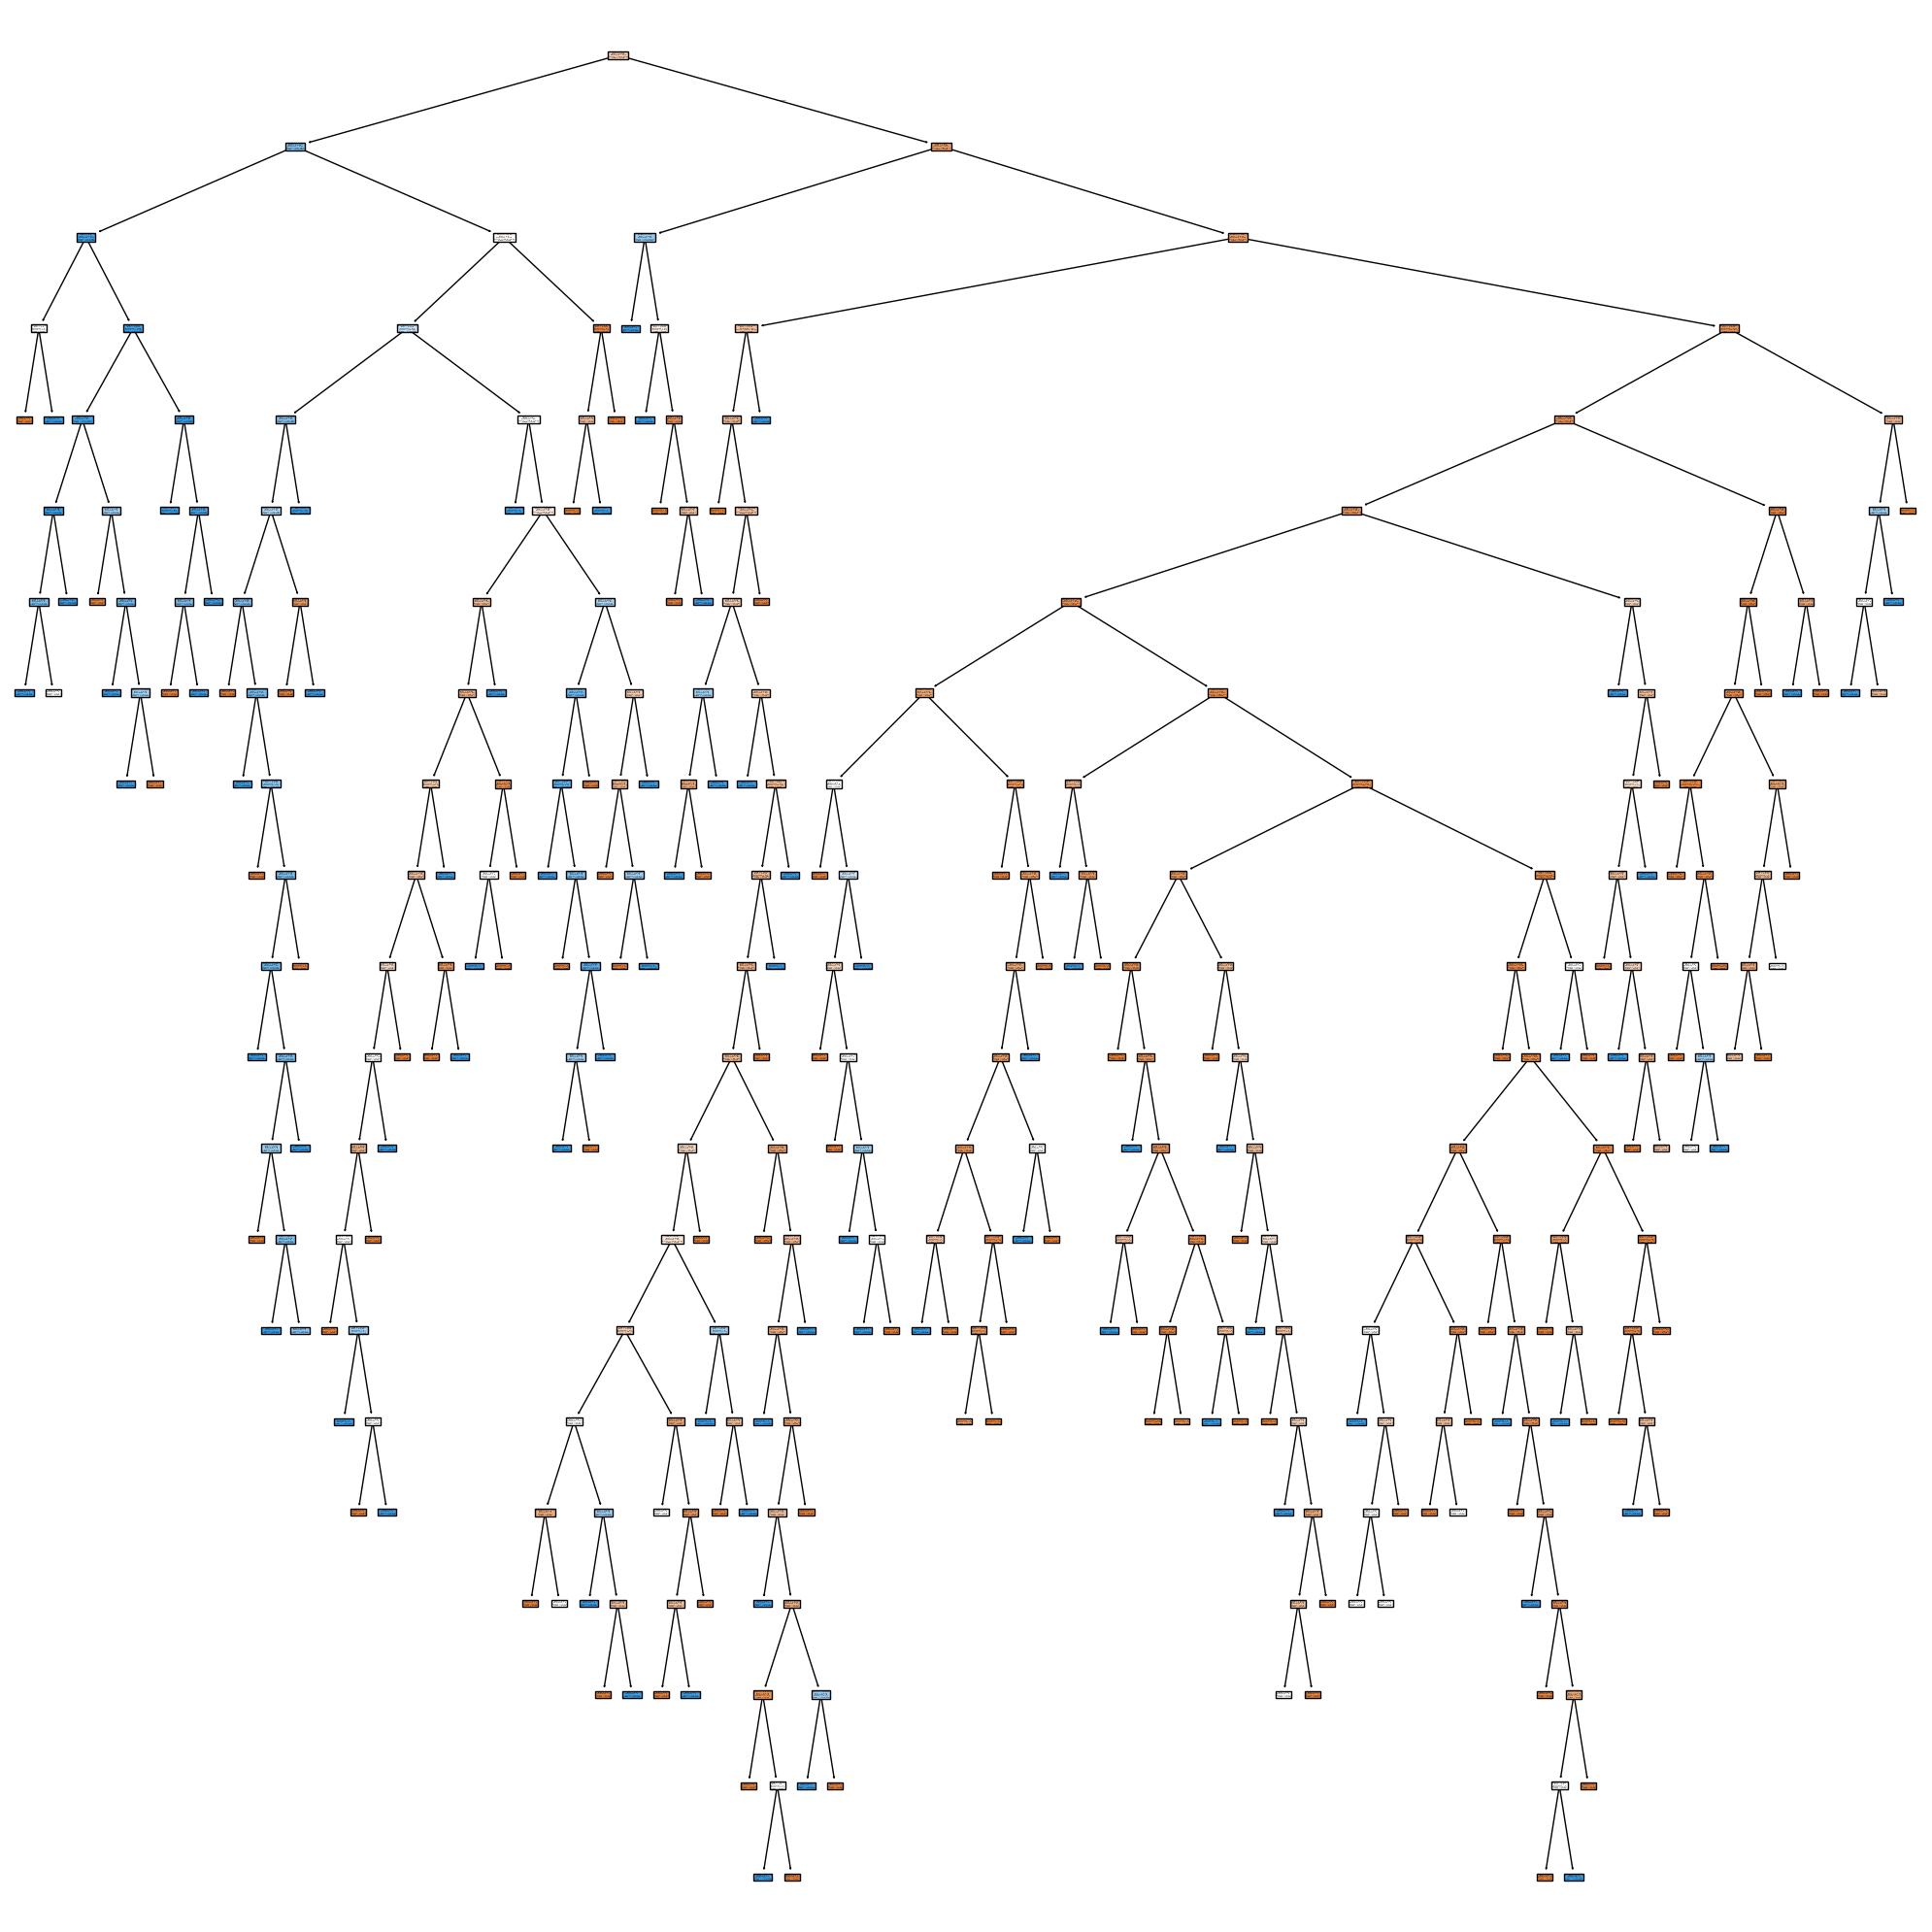

In [17]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 20)) # graph kitna bara nazar ana chahiye 
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died", "Survived"],
    filled = True
    
)
plt.tight_layout()
plt.show()

# Dicision tree with pre -pruning

depth = 2  accuarcy = 0.7653631284916201
depth = 2  precision = 0.8809523809523809
depth = 2  f1_score  = 0.6379310344827587
depth = 2  recall_score = 0.5
depth = 2  cm  = [[100   5]
 [ 37  37]]
depth = 3  accuarcy = 0.7988826815642458
depth = 3  precision = 0.796875
depth = 3  f1_score  = 0.7391304347826086
depth = 3  recall_score = 0.6891891891891891
depth = 3  cm  = [[92 13]
 [23 51]]
depth = 4  accuarcy = 0.7988826815642458
depth = 4  precision = 0.8392857142857143
depth = 4  f1_score  = 0.7230769230769231
depth = 4  recall_score = 0.6351351351351351
depth = 4  cm  = [[96  9]
 [27 47]]


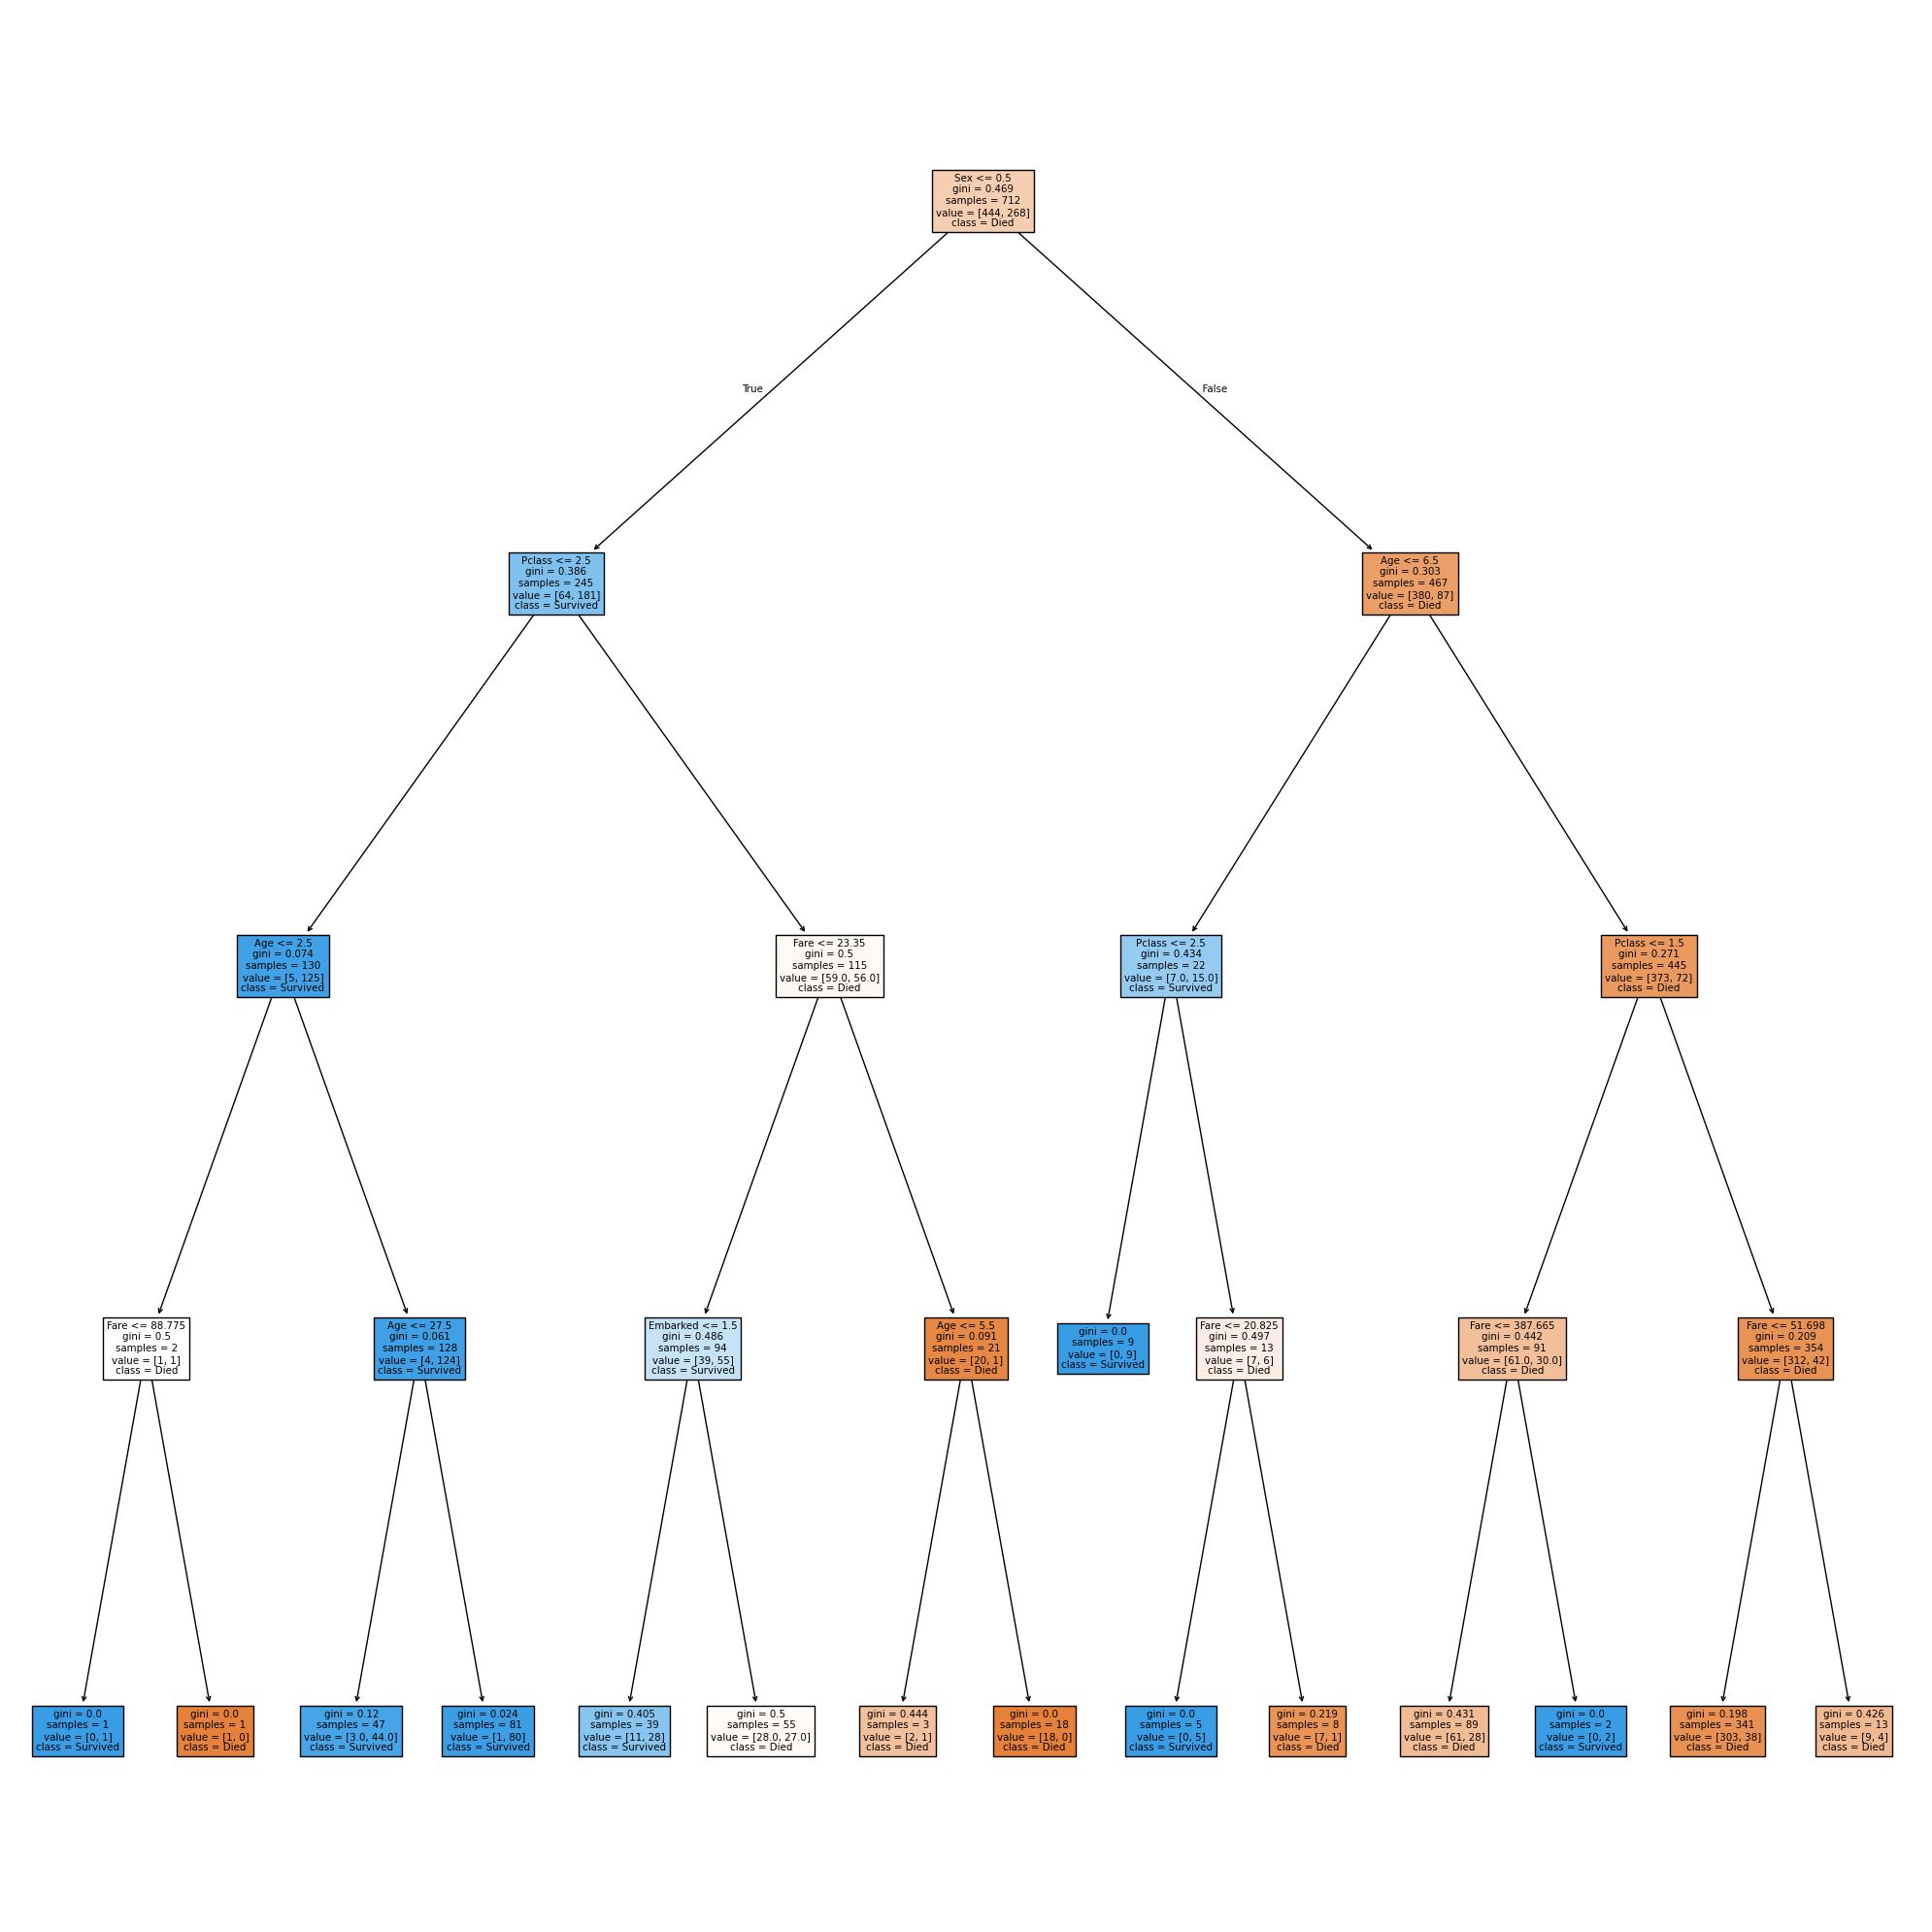

depth = 5  accuarcy = 0.7988826815642458
depth = 5  precision = 0.8275862068965517
depth = 5  f1_score  = 0.7272727272727273
depth = 5  recall_score = 0.6486486486486487
depth = 5  cm  = [[95 10]
 [26 48]]
depth = 6  accuarcy = 0.8044692737430168
depth = 6  precision = 0.8421052631578947
depth = 6  f1_score  = 0.732824427480916
depth = 6  recall_score = 0.6486486486486487
depth = 6  cm  = [[96  9]
 [26 48]]
depth = 7  accuarcy = 0.7988826815642458
depth = 7  precision = 0.8166666666666667
depth = 7  f1_score  = 0.7313432835820896
depth = 7  recall_score = 0.6621621621621622
depth = 7  cm  = [[94 11]
 [25 49]]
depth = 8  accuarcy = 0.7932960893854749
depth = 8  precision = 0.8032786885245902
depth = 8  f1_score  = 0.725925925925926
depth = 8  recall_score = 0.6621621621621622
depth = 8  cm  = [[93 12]
 [25 49]]
depth = 9  accuarcy = 0.7932960893854749
depth = 9  precision = 0.7846153846153846
depth = 9  f1_score  = 0.7338129496402878
depth = 9  recall_score = 0.6891891891891891
depth = 

In [18]:
# Evaluate the model 
max_depths = [2,3,4,5,6,7,8,9,10]
for depth in max_depths :
    model = DecisionTreeClassifier(max_depth = depth)
    model.fit(X_train, Y_train)
    y = model.predict(X_test)
    print(f"depth = {depth}  accuarcy = {accuracy_score(Y_test, y)}")
    print(f"depth = {depth}  precision = {precision_score(Y_test, y)}")
    print(f"depth = {depth}  f1_score  = {f1_score(Y_test, y)}")
    print(f"depth = {depth}  recall_score = {recall_score(Y_test, y)}")
    print(f"depth = {depth}  cm  = {confusion_matrix(Y_test, y)}")
    if depth == 4: 
        plt.figure(figsize=(20, 20)) # graph kitna bara nazar ana chahiye 
        plot_tree(
            model,
            feature_names = X.columns,
            class_names = ["Died", "Survived"],
            filled = True
    
            )
        plt.tight_layout()
        plt.show()

sample = 10  accuarcy = 0.7988826815642458
sample = 10  precision = 0.8392857142857143
sample = 10  f1_score  = 0.7230769230769231
sample = 10  recall_score = 0.6351351351351351
sample = 10  cm  = [[96  9]
 [27 47]]
sample = 15  accuarcy = 0.7988826815642458
sample = 15  precision = 0.8392857142857143
sample = 15  f1_score  = 0.7230769230769231
sample = 15  recall_score = 0.6351351351351351
sample = 15  cm  = [[96  9]
 [27 47]]
sample = 20  accuarcy = 0.7988826815642458
sample = 20  precision = 0.8392857142857143
sample = 20  f1_score  = 0.7230769230769231
sample = 20  recall_score = 0.6351351351351351
sample = 20  cm  = [[96  9]
 [27 47]]
sample = 25  accuarcy = 0.7932960893854749
sample = 25  precision = 0.8245614035087719
sample = 25  f1_score  = 0.7175572519083969
sample = 25  recall_score = 0.6351351351351351
sample = 25  cm  = [[95 10]
 [27 47]]
sample = 30  accuarcy = 0.7932960893854749
sample = 30  precision = 0.8245614035087719
sample = 30  f1_score  = 0.7175572519083969
sampl

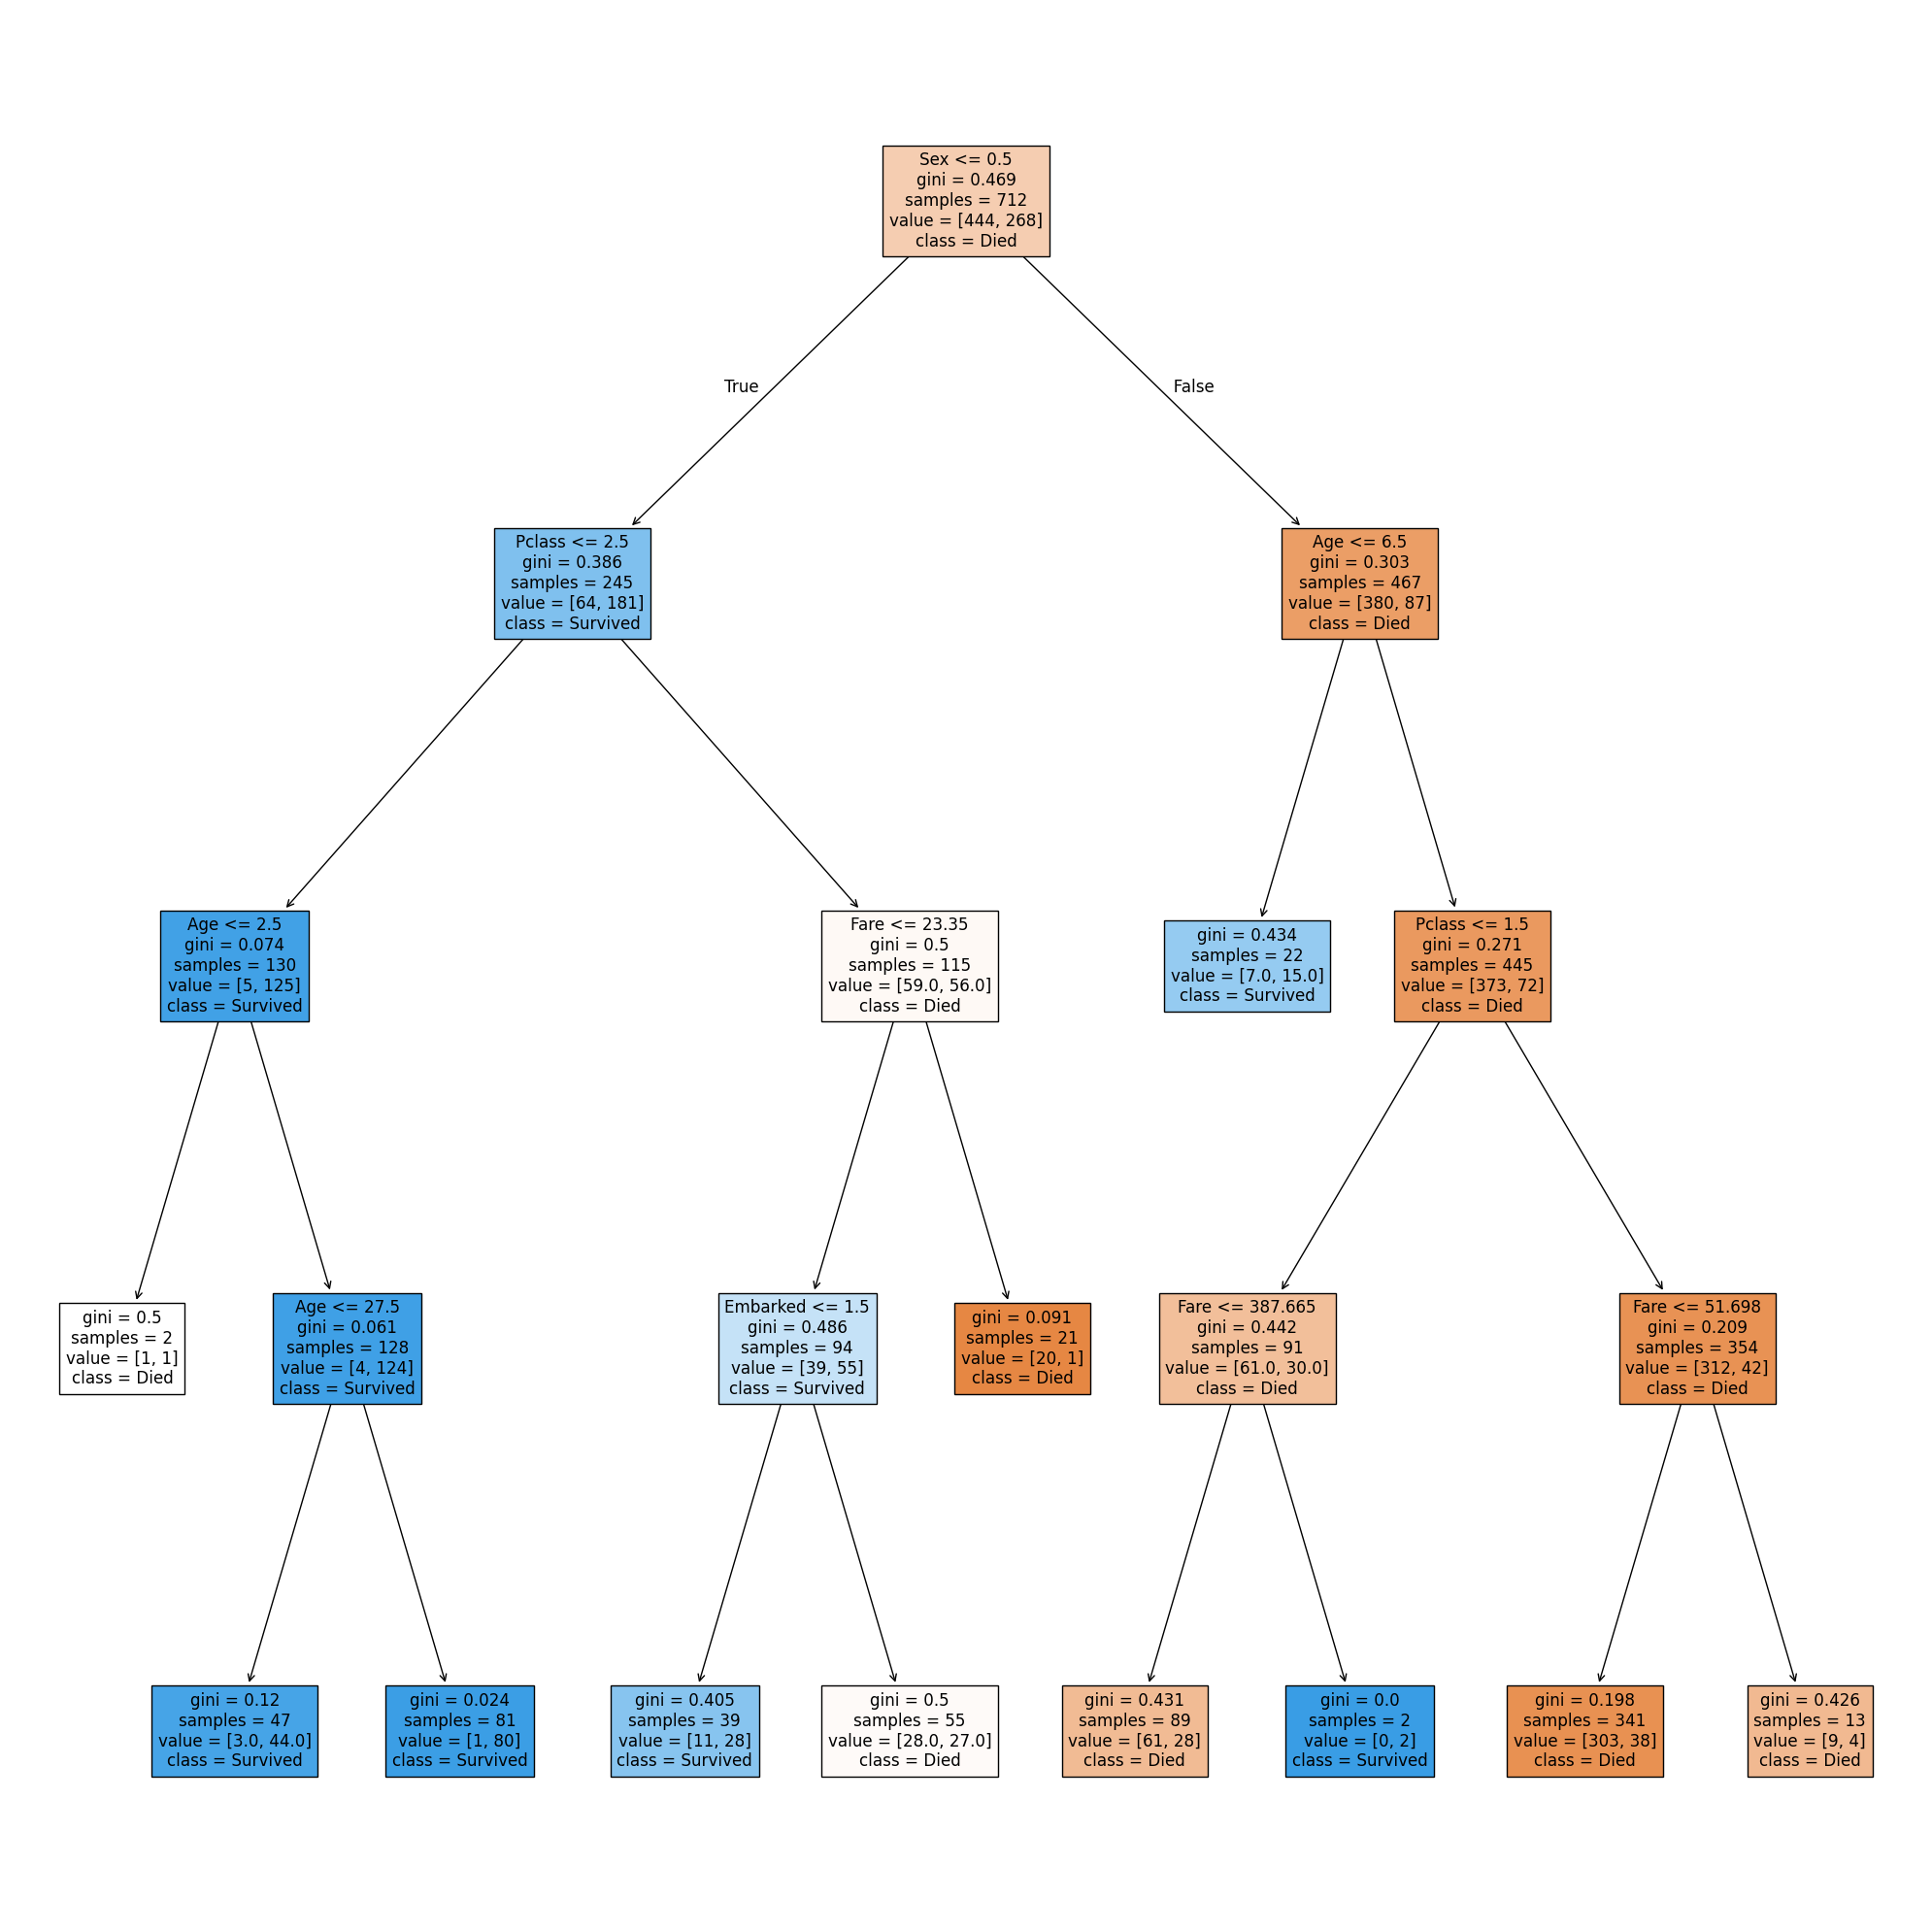

In [19]:
min_samples_splits = [10,15,20,25,30,35,40,45,50,55,60,70,75,80,90]
for samples in min_samples_splits :
    model = DecisionTreeClassifier(max_depth = 4, min_samples_split = samples)
    model.fit(X_train, Y_train)
    y = model.predict(X_test)
    print(f"sample = {samples}  accuarcy = {accuracy_score(Y_test, y)}")
    print(f"sample = {samples}  precision = {precision_score(Y_test, y)}")
    print(f"sample = {samples}  f1_score  = {f1_score(Y_test, y)}")
    print(f"sample = {samples}  recall_score = {recall_score(Y_test, y)}")
    print(f"sample = {samples}  cm  = {confusion_matrix(Y_test, y)}")
    if samples == 15 :
        plt.figure(figsize=(20, 20)) # graph kitna bara nazar ana chahiye 
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died", "Survived"],
    filled = True
    
)
plt.tight_layout()
plt.show()

# Dicision Tree post-pruning

In [20]:
full_tree = DecisionTreeClassifier(random_state =  42)
full_tree.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [21]:
path = full_tree.cost_complexity_pruning_path(X_train, Y_train)
ccp_alpha = path.ccp_alphas
print(ccp_alpha)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [22]:
tree = []
for alpha in ccp_alpha :
    model = DecisionTreeClassifier(random_state =  42, ccp_alpha = alpha)
    model.fit(X_train, Y_train)  
    
    tree.append((model,alpha))

In [24]:
best_alpha = 0
best_acc = 0 
for model,alpha in tree :
    curr_acc = model.score(X_test, Y_test)
    if curr_acc > best_acc :
        best_acc = curr_acc
        best_alpha = alpha 

print(best_acc, best_alpha)

0.8379888268156425 0.0015407231242023183


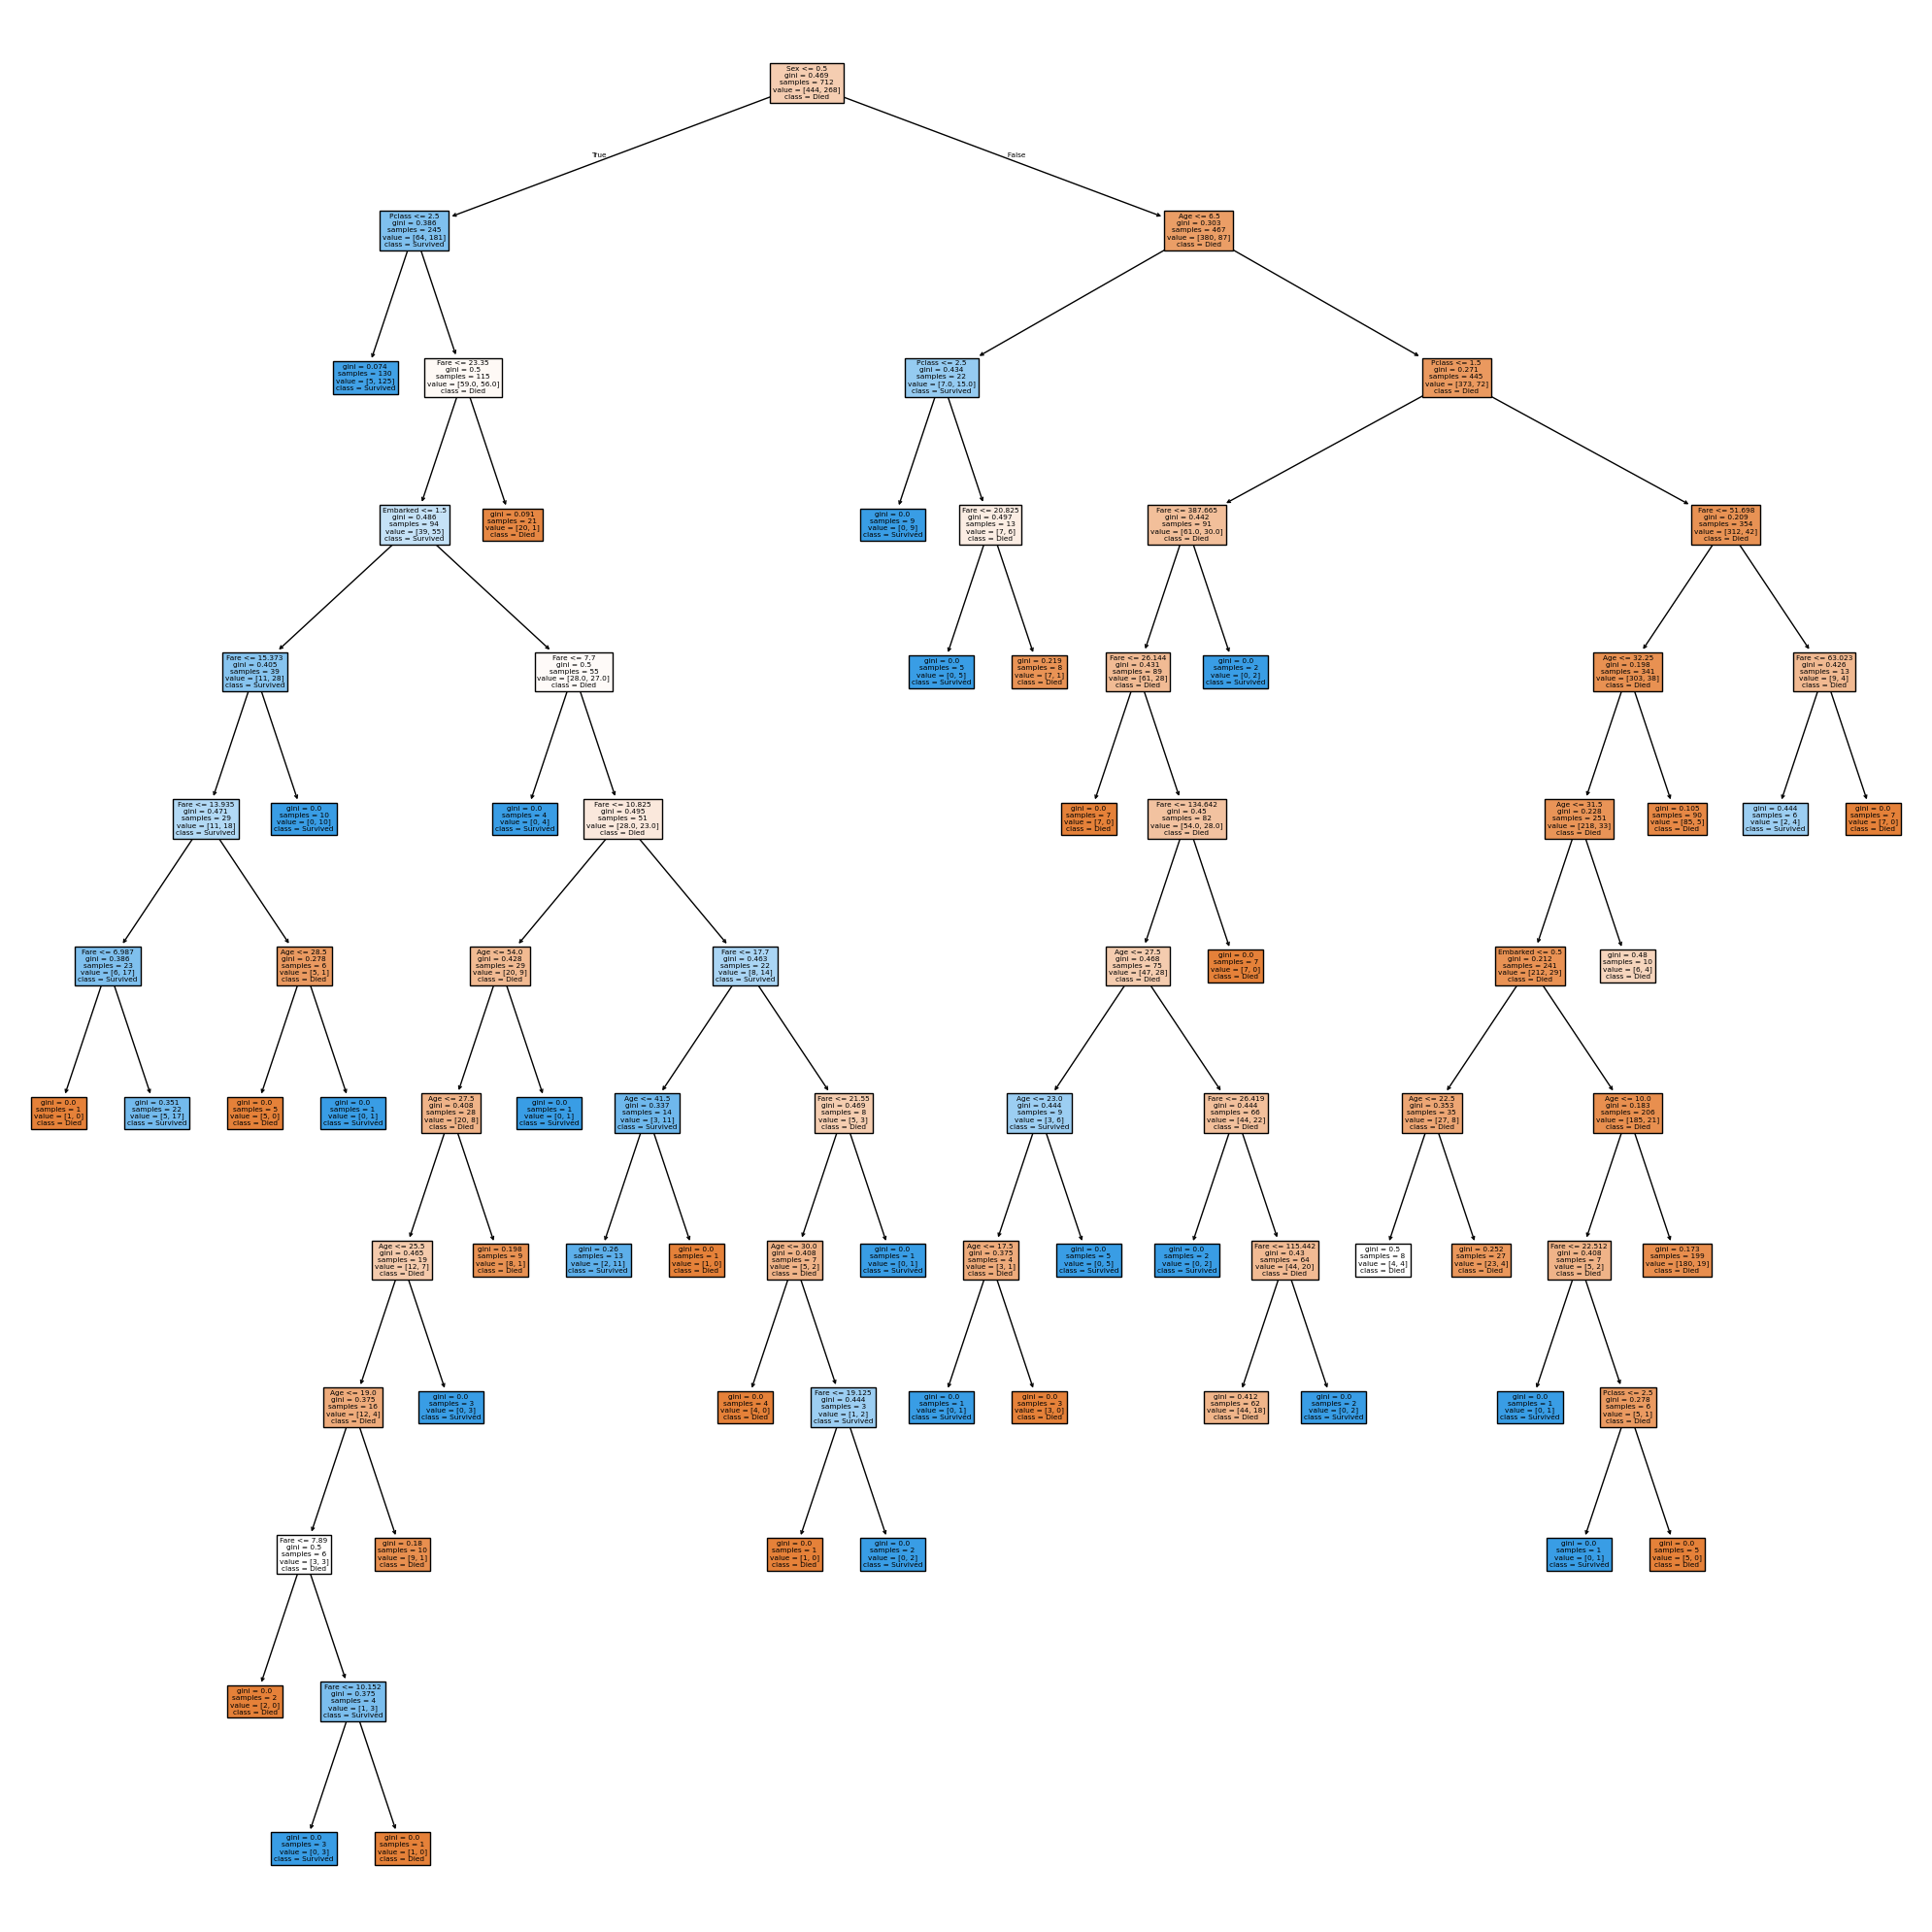

In [26]:
best_tree =  DecisionTreeClassifier(ccp_alpha = best_alpha)
best_tree.fit(X_train , Y_train)
plt.figure(figsize=(20, 20)) # graph kitna bara nazar ana chahiye 
plot_tree(
    best_tree,
    feature_names = X.columns,
    class_names = ["Died", "Survived"],
    filled = True
    
)
plt.tight_layout()
plt.show()

In [27]:
acc = best_tree.score(X_test, Y_test)
print(acc)

0.8324022346368715
